In [13]:
pip install findspark

In [14]:
import os
import sys
import time
import logging
import warnings
import sqlite3
import zipfile
from datetime import datetime

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure Logging for Professional Software Engineering Standards
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout)
    ]
)
logger = logging.getLogger("BigDataPipeline")

# Initialize FindSpark to locate PySpark installation
import findspark
findspark.init()

# Import PySpark modules
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.pipeline import Pipeline
from pyspark.sql.window import Window

# Import Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set Plotly renderer for Colab
import plotly.io as pio
pio.renderers.default = "colab"

logger.info("Environment setup completed successfully.")

INFO:BigDataPipeline:Environment setup completed successfully.


In [15]:
# SPARK CONFIGURATION

# Spark Configuration
# We configure the SparkSession for optimal performance on Colab.
# Key configurations include memory allocation, adaptive execution, and serialization.

def create_spark_session():
    """
    Creates a configured SparkSession optimized for Big Data processing.

    Returns:
        SparkSession: Configured Spark session.
    """
    spark = SparkSession.builder \
        .appName("LondonGTFS_PeakDemandForecasting") \
        .config("spark.sql.adaptive.enabled", "true") \
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
        .config("spark.sql.shuffle.partitions", "200") \
        .config("spark.driver.memory", "4g") \
        .config("spark.executor.memory", "4g") \
        .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
        .config("spark.kryoserializer.buffer.max", "512m") \
        .config("spark.sql.broadcastTimeout", "600") \
        .getOrCreate()

    # Set log level to WARN to reduce noise
    spark.sparkContext.setLogLevel("WARN")
    return spark

spark = create_spark_session()
logger.info(f"Spark Version: {spark.version}")
logger.info(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

INFO:BigDataPipeline:Spark Version: 4.0.3
INFO:BigDataPipeline:Spark UI available at: http://21cebce3e619:4040


In [17]:
# DATA INGESTION

ZIP_FILE = "itm_london_gtfs.zip"
BASE_PATH = "data/"

def extract_gtfs_zip(zip_path, extract_to):
    """Extracts the GTFS zip file if the target directory is empty or doesn't exist."""
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    if len(os.listdir(extract_to)) == 0:
        logger.info(f"Extracting {zip_path} to {extract_to}...")
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to)
            logger.info("Extraction completed successfully.")
        except Exception as e:
            logger.error(f"Error extracting zip file: {e}")
            raise e
    else:
        logger.info(f"Data directory {extract_to} already contains files. Skipping extraction.")

extract_gtfs_zip(ZIP_FILE, BASE_PATH)

def load_gtfs_table(file_name):
    """Loads a GTFS CSV file into a Spark DataFrame."""
    path = os.path.join(BASE_PATH, file_name)
    if not os.path.exists(path):
        logger.warning(f"File {file_name} not found at {path}. Returning None.")
        return None

    try:
        df = spark.read.option("header", "true") \
                       .option("inferSchema", "true") \
                       .option("delimiter", ",") \
                       .option("escape", "\"") \
                       .csv(path)
        row_count = df.count()
        logger.info(f"Loaded {file_name}: {row_count} rows")
        return df
    except Exception as e:
        logger.error(f"Error loading {file_name}: {e}")
        return None

logger.info("### Loading GTFS Tables ###")
agency_df = load_gtfs_table("agency.txt")
routes_df = load_gtfs_table("routes.txt")
stops_df = load_gtfs_table("stops.txt")
trips_df = load_gtfs_table("trips.txt")
stop_times_df = load_gtfs_table("stop_times.txt")
calendar_df = load_gtfs_table("calendar.txt")
calendar_dates_df = load_gtfs_table("calendar_dates.txt")
frequencies_df = load_gtfs_table("frequencies.txt")
transfers_df = load_gtfs_table("shapes.txt")
feed_info_df = load_gtfs_table("feed_info.txt")

logger.info("### Schema Verification ###")
for name, df in [("Agency", agency_df), ("Routes", routes_df), ("Stops", stops_df),
                 ("Trips", trips_df), ("Stop Times", stop_times_df), ("Calendar", calendar_df)]:
    if df is not None:
        logger.info(f"{name} Schema:")
        df.printSchema()

INFO:BigDataPipeline:Data directory data/ already contains files. Skipping extraction.
INFO:BigDataPipeline:### Loading GTFS Tables ###
INFO:BigDataPipeline:Loaded agency.txt: 57 rows
INFO:BigDataPipeline:Loaded routes.txt: 1063 rows
INFO:BigDataPipeline:Loaded stops.txt: 24782 rows
INFO:BigDataPipeline:Loaded trips.txt: 456521 rows
INFO:BigDataPipeline:Loaded stop_times.txt: 17257720 rows
INFO:BigDataPipeline:Loaded calendar.txt: 461 rows
INFO:BigDataPipeline:Loaded calendar_dates.txt: 35353 rows
INFO:BigDataPipeline:Loaded frequencies.txt: 35 rows
INFO:BigDataPipeline:Loaded shapes.txt: 116940 rows
INFO:BigDataPipeline:Loaded feed_info.txt: 1 rows
INFO:BigDataPipeline:### Schema Verification ###
INFO:BigDataPipeline:Agency Schema:
INFO:BigDataPipeline:Routes Schema:
INFO:BigDataPipeline:Stops Schema:
INFO:BigDataPipeline:Trips Schema:
INFO:BigDataPipeline:Stop Times Schema:
INFO:BigDataPipeline:Calendar Schema:


root
 |-- agency_id: string (nullable = true)
 |-- agency_name: string (nullable = true)
 |-- agency_url: string (nullable = true)
 |-- agency_timezone: string (nullable = true)
 |-- agency_lang: string (nullable = true)
 |-- agency_phone: string (nullable = true)
 |-- agency_noc: string (nullable = true)

root
 |-- route_id: integer (nullable = true)
 |-- agency_id: string (nullable = true)
 |-- route_short_name: string (nullable = true)
 |-- route_long_name: string (nullable = true)
 |-- route_type: integer (nullable = true)

root
 |-- stop_id: string (nullable = true)
 |-- stop_code: string (nullable = true)
 |-- stop_name: string (nullable = true)
 |-- stop_lat: double (nullable = true)
 |-- stop_lon: double (nullable = true)
 |-- wheelchair_boarding: integer (nullable = true)
 |-- location_type: integer (nullable = true)
 |-- parent_station: string (nullable = true)
 |-- platform_code: string (nullable = true)

root
 |-- route_id: integer (nullable = true)
 |-- service_id: integer

In [18]:
# DATA VALIDATION & QUALITY ANALYSIS (OPTIMIZED)

def analyze_data_quality(df, name, sample_size=200000):
    """Performs comprehensive data quality analysis on a sampled DataFrame."""
    if df is None:
        print(f"⚠️ WARNING: {name} DataFrame is None. Skipping analysis.")
        return

    total_rows_full = df.count()

    if sample_size and total_rows_full > sample_size:
        fraction = sample_size / total_rows_full
        df_sample = df.sample(False, fraction, seed=42).limit(sample_size)
        print(f"🚀 Using Sampled Data: {sample_size:,} rows (out of {total_rows_full:,}) for faster analysis.")
        analysis_df = df_sample
        reference_rows = total_rows_full
    else:
        print(f"✅ Using Full Dataset: {total_rows_full:,} rows.")
        analysis_df = df
        reference_rows = total_rows_full

    actual_sample_count = analysis_df.count()

    print(f"\n{'='*60}")
    print(f"📊 DATA QUALITY REPORT: {name}")
    print(f"{'='*60}")
    print(f"✅ Total Rows in Dataset: {reference_rows:,}")
    print(f"🔍 Analyzing Sample Size: {actual_sample_count:,}")

    # --- 1. Null Value Analysis ---
    print("\n🔍 Null Value Analysis:")
    null_counts = analysis_df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in analysis_df.columns])
    null_pd = null_counts.toPandas().T
    null_pd.columns = ['Null_Count']
    null_pd['Null_Percentage'] = (null_pd['Null_Count'] / actual_sample_count) * 100

    null_pd_filtered = null_pd[null_pd['Null_Count'] > 0]

    if not null_pd_filtered.empty:
        styled_df = null_pd_filtered.style.background_gradient(subset=['Null_Percentage'], cmap='YlOrRd')
        styled_df = styled_df.format({'Null_Percentage': '{:.2f}%'})
        display(styled_df)
    else:
        print("   ✅ No null values found in any column.")

    # --- 2. Duplicate Detection ---
    print("\n🔄 Duplicate Detection:")
    distinct_count = analysis_df.dropDuplicates().count()
    dup_count = actual_sample_count - distinct_count

    if dup_count > 0:
        print(f"   ⚠️ Found {dup_count:,} duplicate rows in sample ({(dup_count/actual_sample_count)*100:.2f}%).")
    else:
        print(f"   ✅ No duplicate rows found in sample.")

    # --- 3. Cardinality Analysis ---
    print("\n🔢 Cardinality Analysis (Top Columns):")
    cardinality_cols = [c for c in analysis_df.columns if analysis_df.schema[c].dataType.typeName() in ['string', 'integer', 'long']]

    if cardinality_cols:
        cols_to_check = cardinality_cols[:10]
        cardinality = analysis_df.select([F.approx_count_distinct(c).alias(c) for c in cols_to_check]).toPandas().T
        cardinality.columns = ['Unique_Values']
        cardinality.index.name = 'Column_Name'
        display(cardinality.style.format({'Unique_Values': '{:,}'}))
    else:
        print("   No suitable columns for cardinality analysis.")

    print(f"{'='*60}\n")

logger.setLevel(logging.INFO)

analyze_data_quality(stop_times_df, "Stop Times", sample_size=200000)
analyze_data_quality(trips_df, "Trips", sample_size=200000)
analyze_data_quality(routes_df, "Routes", sample_size=None)
analyze_data_quality(stops_df, "Stops", sample_size=None)

🚀 Using Sampled Data: 200,000 rows (out of 17,257,720) for faster analysis.

📊 DATA QUALITY REPORT: Stop Times
✅ Total Rows in Dataset: 17,257,720
🔍 Analyzing Sample Size: 200,000

🔍 Null Value Analysis:


,Null_Count,Null_Percentage
stop_headsign,200000,100.00%
shape_dist_traveled,200000,100.00%



🔄 Duplicate Detection:
   ✅ No duplicate rows found in sample.

🔢 Cardinality Analysis (Top Columns):


,Unique_Values
Column_Name,
trip_id,"158,812"
arrival_time,"65,726"
departure_time,"65,726"
stop_id,"20,708"
stop_sequence,105
stop_headsign,0
pickup_type,2
drop_off_type,2
shape_dist_traveled,0



🚀 Using Sampled Data: 200,000 rows (out of 456,521) for faster analysis.

📊 DATA QUALITY REPORT: Trips
✅ Total Rows in Dataset: 456,521
🔍 Analyzing Sample Size: 200,000

🔍 Null Value Analysis:


...

,Unique_Values
Column_Name,
route_id,"1,073"
agency_id,55
route_short_name,938
route_long_name,0
route_type,7



✅ Using Full Dataset: 24,782 rows.

📊 DATA QUALITY REPORT: Stops
✅ Total Rows in Dataset: 24,782
🔍 Analyzing Sample Size: 24,782

🔍 Null Value Analysis:


,Null_Count,Null_Percentage
stop_code,1655,6.68%
parent_station,23914,96.50%
platform_code,24604,99.28%



🔄 Duplicate Detection:
   ✅ No duplicate rows found in sample.

🔢 Cardinality Analysis (Top Columns):


,Unique_Values
Column_Name,
stop_id,"23,801"
stop_code,"23,171"
stop_name,"13,618"
wheelchair_boarding,1
location_type,3
parent_station,442
platform_code,70


In [19]:
# DATA PREPROCESSING & CLEANING

# Data Preprocessing
# Based on Data Quality Analysis, we perform targeted cleaning:
# 1. Dropping high-null columns (`block_id`, `shape_id`) to optimize shuffle performance.
# 2. Relying on `route_short_name` since `route_long_name` is 100% null.
# 3. Filtering for valid weekday services only.

logger.info("### Starting Advanced Preprocessing ###")

# 1. Optimize Trips DataFrame: Drop high-null columns identified in QA
trips_clean = trips_df.drop("block_id", "shape_id")

# 2. Clean Stop Times: Remove rows with missing critical times
stop_times_clean = stop_times_df.filter(
    (F.col("arrival_time").isNotNull()) &
    (F.col("departure_time").isNotNull()) &
    (F.col("stop_sequence").isNotNull())
)

# 3. Convert Time Strings to Seconds since Midnight
def time_to_seconds(time_col):
    """Converts HH:MM:SS string to seconds since midnight."""
    parts = F.split(time_col, ":")
    return (parts.getItem(0).cast("int") * 3600) + \
           (parts.getItem(1).cast("int") * 60) + \
           parts.getItem(2).cast("int")

stop_times_clean = stop_times_clean.withColumn("arrival_sec", time_to_seconds("arrival_time")) \
                                   .withColumn("departure_sec", time_to_seconds("departure_time"))

# 4. Join Trips with Routes (Select only needed columns to reduce width)
trips_routes = trips_clean.join(
    routes_df.select("route_id", "route_short_name", "route_type"),
    on="route_id",
    how="inner"
)

# 5. Join Stop Times with Trips/Routes
full_dataset = stop_times_clean.join(trips_routes, on="trip_id", how="inner")

# 6. Filter for Valid Weekday Services
calendar_weekdays = calendar_df.filter(
    (F.col("monday") == 1) | (F.col("tuesday") == 1) | (F.col("wednesday") == 1) |
    (F.col("thursday") == 1) | (F.col("friday") == 1)
)

active_trip_ids = calendar_weekdays.join(
    trips_clean.select("trip_id", "service_id"),
    on="service_id",
    how="inner"
).select("trip_id").distinct()

full_dataset = full_dataset.join(active_trip_ids, on="trip_id", how="inner")

logger.info(f"Preprocessed Dataset Size: {full_dataset.count()} rows")
logger.info("Optimization: Dropped block_id, shape_id due to >99% nullity")

# Cache the dataset as it will be used repeatedly
full_dataset.cache()

INFO:BigDataPipeline:### Starting Advanced Preprocessing ###
INFO:BigDataPipeline:Preprocessed Dataset Size: 8178359 rows
INFO:BigDataPipeline:Optimization: Dropped block_id, shape_id due to >99% nullity


DataFrame[trip_id: string, arrival_time: string, departure_time: string, stop_id: string, stop_sequence: int, stop_headsign: string, pickup_type: int, drop_off_type: int, shape_dist_traveled: string, timepoint: int, arrival_sec: int, departure_sec: int, route_id: int, service_id: int, trip_headsign: string, direction_id: int, wheelchair_accessible: int, vehicle_journey_code: string, route_short_name: string, route_type: int]

In [22]:
def engineer_features(df):
    """Creates predictive features from raw GTFS data."""

    # 1. Temporal Features
    df = df.withColumn("hour", F.hour(F.from_unixtime(F.col("arrival_sec")))) \
           .withColumn("minute", F.minute(F.from_unixtime(F.col("arrival_sec")))) \
           .withColumn("is_peak", F.when((F.col("hour") >= 7) & (F.col("hour") <= 9) |
                                         (F.col("hour") >= 16) & (F.col("hour") <= 18), 1).otherwise(0))

    # Add timepoint flag (1=Timing Point, 0/Null=Non-timing)
    df = df.withColumn("is_timepoint", F.when(F.col("timepoint") == 1, 1).otherwise(0))

    # 2. Route-Level Features
    df = df.withColumn("segment_duration", F.col("departure_sec") - F.col("arrival_sec"))

    window_route_hour = Window.partitionBy("route_id", "hour")
    window_trip = Window.partitionBy("trip_id")
    window_stop_hour = Window.partitionBy("stop_id", "hour")

    # Number of stops in the trip (Route Length Proxy)
    df = df.withColumn("stops_in_trip", F.count("*").over(window_trip))

    # Service Frequency: Count departures per route per hour
    df = df.withColumn("route_hourly_frequency", F.count("*").over(window_route_hour))

    # 3. Stop-Level Features
    df = df.withColumn("stop_hourly_activity", F.count("*").over(window_stop_hour))

    # 4. Headway Estimate (Inverse of Frequency)
    df = df.withColumn("estimated_headway_sec",
                       F.when(F.col("route_hourly_frequency") > 0,
                              3600 / F.col("route_hourly_frequency")).otherwise(None))

    return df

full_dataset_fe = engineer_features(full_dataset)

# Define Numeric Columns for Casting (Exclude IDs)
numeric_feature_cols = ["hour", "is_peak", "is_timepoint", "stops_in_trip",
                        "route_hourly_frequency", "estimated_headway_sec",
                        "stop_hourly_activity", "segment_duration"]

# Ensure numeric types ONLY for actual numeric features
for col in numeric_feature_cols:
    full_dataset_fe = full_dataset_fe.withColumn(col, F.col(col).cast("double"))

logger.info("Feature engineering completed. IDs kept as strings for indexing.")

INFO:BigDataPipeline:Feature engineering completed. IDs kept as strings for indexing.


In [23]:
# SPARK SQL ANALYSIS

full_dataset_fe.createOrReplaceTempView("gtfs_full")

top_routes_query = """
SELECT route_id, route_short_name, hour, AVG(route_hourly_frequency) as avg_frequency
FROM gtfs_full
GROUP BY route_id, route_short_name, hour
ORDER BY avg_frequency DESC
LIMIT 10
"""
top_routes_df = spark.sql(top_routes_query)
logger.info("Top 10 Busiest Routes:")
top_routes_df.show()

# Aggregated Dataset for Modeling
aggregated_model_df = spark.sql("""
    SELECT
        route_id,       -- Keep as String
        stop_id,        -- Keep as String
        hour,
        is_peak,
        is_timepoint,
        AVG(stops_in_trip) as avg_stops_in_trip,
        AVG(route_hourly_frequency) as route_frequency,
        AVG(estimated_headway_sec) as avg_headway,
        SUM(stop_hourly_activity) as total_stop_activity,
        AVG(segment_duration) as avg_segment_duration
    FROM gtfs_full
    GROUP BY route_id, stop_id, hour, is_peak, is_timepoint
""")

aggregated_model_df = aggregated_model_df.na.drop()
logger.info(f"Aggregated Modeling Dataset Size: {aggregated_model_df.count()} rows")

INFO:BigDataPipeline:Top 10 Busiest Routes:


+--------+----------------+----+-------------+
|route_id|route_short_name|hour|avg_frequency|
+--------+----------------+----+-------------+
|10423673|        Northern|18.0|       5181.0|
|11645722|      Piccadilly|18.0|       5118.0|
|10423673|        Northern| 8.0|       5072.0|
|11645722|      Piccadilly|19.0|       5070.0|
|11645722|      Piccadilly|17.0|       5055.0|
|10423673|        Northern|17.0|       5047.0|
|11645722|      Piccadilly| 8.0|       5040.0|
|11645722|      Piccadilly| 9.0|       4986.0|
|11645722|      Piccadilly|16.0|       4908.0|
|11645722|      Piccadilly| 7.0|       4848.0|
+--------+----------------+----+-------------+



INFO:BigDataPipeline:Aggregated Modeling Dataset Size: 1101084 rows


In [28]:
# Define numeric columns for statistical analysis
stats_cols = ["hour", "is_peak", "avg_stops_in_trip", "route_frequency",
              "avg_headway", "total_stop_activity", "avg_segment_duration"]

# Basic Statistical Summary (Mean, Std, Min, Max)
logger.info("Calculating Basic Statistics...")
basic_stats_df = aggregated_model_df.select(stats_cols).describe()
logger.info("Basic Statistics Summary:")
basic_stats_df.show()

INFO:BigDataPipeline:Calculating Basic Statistics...
INFO:BigDataPipeline:Basic Statistics Summary:


+-------+-----------------+------------------+-----------------+-----------------+------------------+-------------------+--------------------+
|summary|             hour|           is_peak|avg_stops_in_trip|  route_frequency|       avg_headway|total_stop_activity|avg_segment_duration|
+-------+-----------------+------------------+-----------------+-----------------+------------------+-------------------+--------------------+
|  count|          1101084|           1101084|          1101084|          1101084|           1101084|            1101084|             1101084|
|   mean|12.49643351460924|0.2855186343639541|43.86208547405802|660.7881778320274|14.507022288203096|  287.5409805246466|  0.9931275133090605|
| stddev|6.474251100610494|0.4516612990560326|13.22485193985906|578.8327090011352|  49.2939370313185|  698.9799110858213|   48.00795007599388|
|    min|              0.0|               0.0|              2.0|              1.0|0.6948465547191646|                1.0|                 0.0|

In [29]:
# PySpark provides built-in functions for skewness and kurtosis.
# For Median, we use percentile_approx (approximate but efficient for Big Data).

logger.info("Calculating Advanced Statistics (Skewness, Kurtosis, Median)...")

advanced_stats_expr = []
for col in stats_cols:
    advanced_stats_expr.append(F.mean(col).alias(f"{col}_mean"))
    advanced_stats_expr.append(F.stddev(col).alias(f"{col}_std"))
    advanced_stats_expr.append(F.skewness(col).alias(f"{col}_skewness"))
    advanced_stats_expr.append(F.kurtosis(col).alias(f"{col}_kurtosis"))
    # Approximate Median (0.5 percentile)
    advanced_stats_expr.append(F.percentile_approx(col, 0.5).alias(f"{col}_median"))

advanced_stats_df = aggregated_model_df.select(advanced_stats_expr)

# Collect to Pandas for readable display
advanced_stats_pd = advanced_stats_df.toPandas()
logger.info("Advanced Statistics Summary:")
display(advanced_stats_pd.T.style.format("{:.2f}"))

INFO:BigDataPipeline:Calculating Advanced Statistics (Skewness, Kurtosis, Median)...
INFO:BigDataPipeline:Advanced Statistics Summary:


,0
hour_mean,12.50
hour_std,6.47
hour_skewness,-0.17
hour_kurtosis,-0.96
hour_median,13.00
is_peak_mean,0.29
is_peak_std,0.45
is_peak_skewness,0.95
is_peak_kurtosis,-1.10
is_peak_median,0.00


In [30]:
# GroupBy Analysis: Peak vs Off-Peak Demand
logger.info("Analyzing Demand by Peak Status...")
peak_demand_stats = aggregated_model_df.groupBy("is_peak").agg(
    F.count("*").alias("count_records"),
    F.mean("total_stop_activity").alias("avg_demand_proxy"),
    F.stddev("total_stop_activity").alias("std_demand_proxy"),
    F.max("total_stop_activity").alias("max_demand_proxy"),
    F.min("total_stop_activity").alias("min_demand_proxy")
).orderBy("is_peak")

logger.info("Peak vs Off-Peak Statistics:")
peak_demand_stats.show()

INFO:BigDataPipeline:Analyzing Demand by Peak Status...
INFO:BigDataPipeline:Peak vs Off-Peak Statistics:


+-------+-------------+------------------+-----------------+----------------+----------------+
|is_peak|count_records|  avg_demand_proxy| std_demand_proxy|max_demand_proxy|min_demand_proxy|
+-------+-------------+------------------+-----------------+----------------+----------------+
|    0.0|       786704|256.55294367385955|624.7801816464639|         30906.0|             1.0|
|    1.0|       314380| 365.0853934728672|852.0275839989386|         33075.0|             1.0|
+-------+-------------+------------------+-----------------+----------------+----------------+



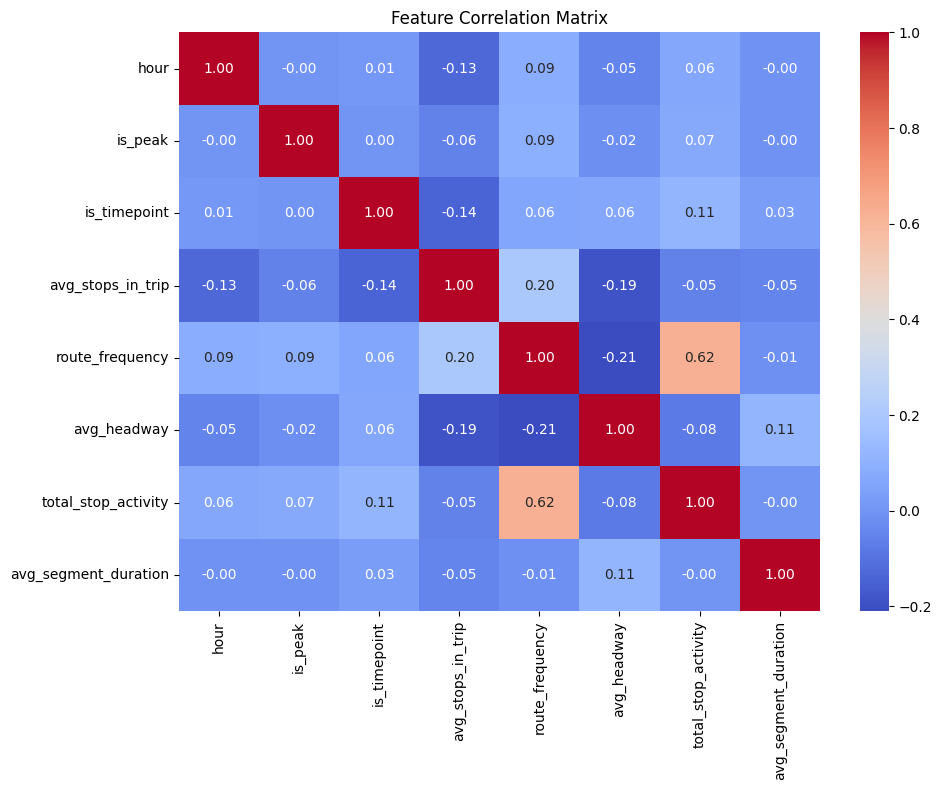

In [31]:
agg_pd = aggregated_model_df.toPandas()

corr_cols = ['hour', 'is_peak', 'is_timepoint', 'avg_stops_in_trip', 'route_frequency',
             'avg_headway', 'total_stop_activity', 'avg_segment_duration']
corr_matrix = agg_pd[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

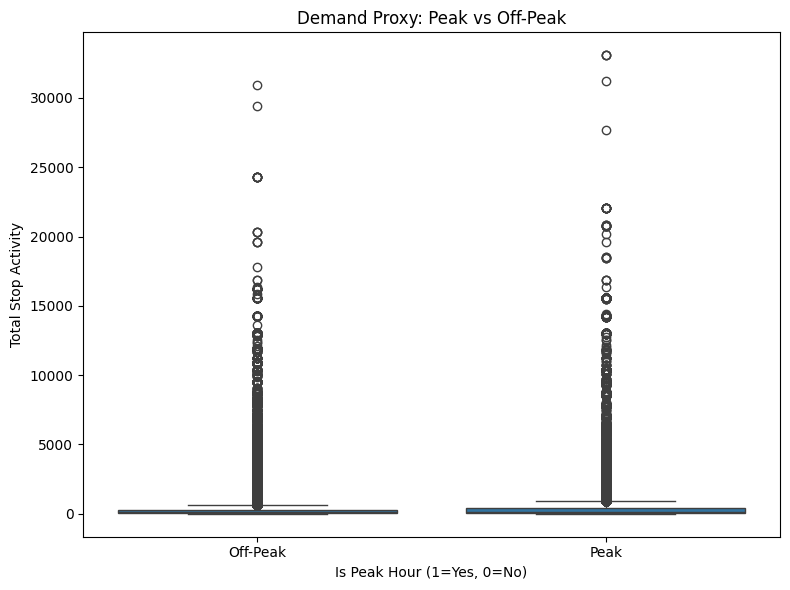

In [27]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_peak', y='total_stop_activity', data=agg_pd)
plt.title("Demand Proxy: Peak vs Off-Peak")
plt.xlabel("Is Peak Hour (1=Yes, 0=No)")
plt.ylabel("Total Stop Activity")
plt.xticks([0, 1], ['Off-Peak', 'Peak'])
plt.tight_layout()
plt.show()

In [34]:
# MACHINE LEARNING PIPELINE

feature_cols = ['hour', 'is_peak', 'is_timepoint', 'avg_stops_in_trip',
                'route_frequency', 'avg_headway', 'avg_segment_duration']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)

target_col = "total_stop_activity"

train_df, test_df = aggregated_model_df.randomSplit([0.7, 0.3], seed=42)
logger.info(f"Training Set: {train_df.count()}, Test Set: {test_df.count()}")

evaluator = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")

lr = LinearRegression(featuresCol="scaledFeatures", labelCol=target_col, maxIter=100)
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])

dt = DecisionTreeRegressor(featuresCol="features", labelCol=target_col, maxDepth=10)
dt_pipeline = Pipeline(stages=[assembler, dt])

rf = RandomForestRegressor(featuresCol="features", labelCol=target_col, numTrees=50, maxDepth=10)
rf_pipeline = Pipeline(stages=[assembler, rf])

gbt = GBTRegressor(featuresCol="features", labelCol=target_col, maxIter=50, maxDepth=5)
gbt_pipeline = Pipeline(stages=[assembler, gbt])

models = {
    "Linear Regression": lr_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosted Tree": gbt_pipeline
}

results = {}

INFO:BigDataPipeline:Training Set: 770860, Test Set: 330224


In [35]:
# MODEL TRAINING & EVALUATION

for name, pipeline in models.items():
    logger.info(f"Training {name}...")
    start_time = time.time()

    model = pipeline.fit(train_df)
    predictions = model.transform(test_df)

    end_time = time.time()
    training_time = end_time - start_time

    rmse = evaluator.evaluate(predictions)

    mae_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")
    r2_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
    ev_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="var")

    mae = mae_eval.evaluate(predictions)
    r2 = r2_eval.evaluate(predictions)
    ev = ev_eval.evaluate(predictions)

    results[name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Explained Variance": ev,
        "Training Time (s)": training_time,
        "Model": model
    }

    logger.info(f"{name} Results: RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.2f}, Time={training_time:.2f}s")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="RMSE")
logger.info("\n### Model Comparison Table ###")
display(results_df)

INFO:BigDataPipeline:Training Linear Regression...
INFO:BigDataPipeline:Linear Regression Results: RMSE=529.22, MAE=213.86, R2=0.43, Time=236.17s
INFO:BigDataPipeline:Training Decision Tree...
INFO:BigDataPipeline:Decision Tree Results: RMSE=373.09, MAE=144.59, R2=0.71, Time=96.73s
INFO:BigDataPipeline:Training Random Forest...
INFO:BigDataPipeline:Random Forest Results: RMSE=393.10, MAE=150.91, R2=0.68, Time=183.17s
INFO:BigDataPipeline:Training Gradient Boosted Tree...
INFO:BigDataPipeline:Gradient Boosted Tree Results: RMSE=372.19, MAE=145.13, R2=0.72, Time=254.64s
INFO:BigDataPipeline:
### Model Comparison Table ###


,RMSE,MAE,R2,Explained Variance,Training Time (s),Model
Gradient Boosted Tree,372.190509,145.125235,0.716151,343923.814028,254.635912,PipelineModel_6015f014d824
Decision Tree,373.093579,144.585082,0.714772,351789.817593,96.733139,PipelineModel_a9ca2e7db134
Random Forest,393.095803,150.910956,0.683369,287229.153798,183.172861,PipelineModel_ff4cb0556832
Linear Regression,529.223103,213.863,0.426103,209199.279387,236.169274,PipelineModel_b455ab745af9


In [36]:
# BIG DATA OPTIMISATION & ALGORITHMIC ANALYSIS

logger.info(f"Number of Partitions in Train DF: {train_df.rdd.getNumPartitions()}")

repartitioned_train = train_df.repartition(10)
logger.info(f"Repartitioned Train DF Partitions: {repartitioned_train.rdd.getNumPartitions()}")

logger.info("### Execution Plan Analysis ###")
spark.sql("SELECT * FROM gtfs_full LIMIT 10").explain(True)

INFO:BigDataPipeline:Number of Partitions in Train DF: 2
INFO:BigDataPipeline:Repartitioned Train DF Partitions: 10
INFO:BigDataPipeline:### Execution Plan Analysis ###


== Parsed Logical Plan ==
'GlobalLimit 10
+- 'LocalLimit 10
   +- 'Project [*]
      +- 'UnresolvedRelation [gtfs_full], [], false

== Analyzed Logical Plan ==
trip_id: string, arrival_time: string, departure_time: string, stop_id: string, stop_sequence: int, stop_headsign: string, pickup_type: int, drop_off_type: int, shape_dist_traveled: string, timepoint: int, arrival_sec: int, departure_sec: int, route_id: int, service_id: int, trip_headsign: string, direction_id: int, wheelchair_accessible: int, vehicle_journey_code: string, route_short_name: string, route_type: int, hour: double, minute: int, is_peak: double, is_timepoint: double, segment_duration: double, ... 4 more fields
GlobalLimit 10
+- LocalLimit 10
   +- Project [trip_id#23088, arrival_time#23089, departure_time#23090, stop_id#23091, stop_sequence#23092, stop_headsign#23093, pickup_type#23094, drop_off_type#23095, shape_dist_traveled#23096, timepoint#23097, arrival_sec#45585, departure_sec#45586, route_id#23049, service_id

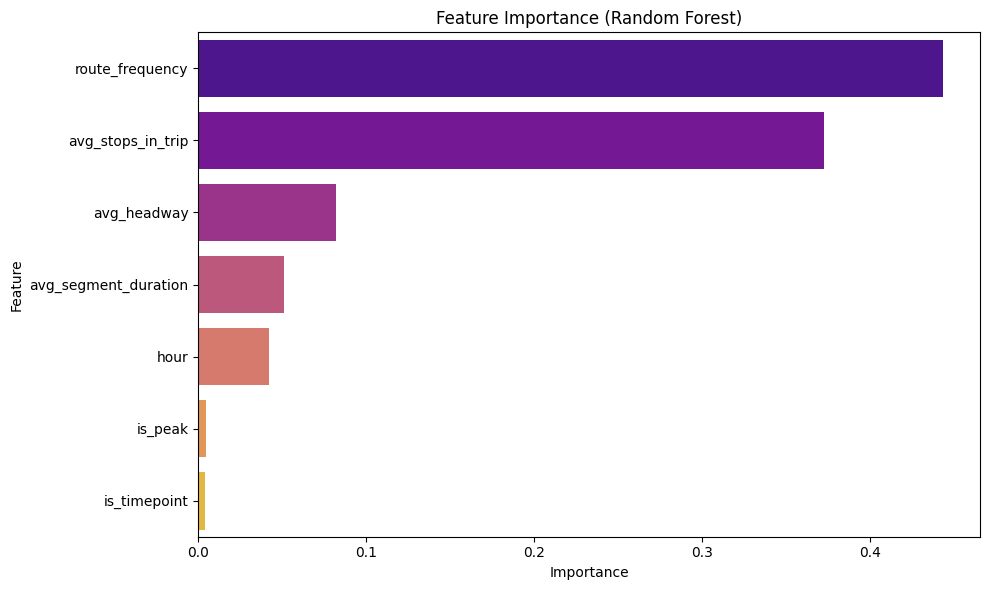

In [38]:
# VISUALISATION OF RESULTS
gb_model_obj = results["Gradient Boosted Tree"]["Model"].stages[-1]
importances = gb_model_obj.featureImportances.toArray()
feat_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='plasma')
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [39]:
# DATABASE INTEGRATION (SQLite)


DB_NAME = "london_gtfs_analytics.db"

def create_database():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute('''CREATE TABLE IF NOT EXISTS model_performance (
        model_name TEXT PRIMARY KEY, rmse REAL, mae REAL, r2 REAL,
        explained_variance REAL, training_time REAL)''')
    cursor.execute('''CREATE TABLE IF NOT EXISTS aggregated_demand (
        route_id TEXT, stop_id TEXT, hour INTEGER, is_peak INTEGER,
        total_stop_activity REAL)''')
    conn.commit()
    conn.close()
    logger.info("SQLite Database created successfully.")

def insert_model_results(results_dict):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    for model_name, metrics in results_dict.items():
        cursor.execute('''INSERT OR REPLACE INTO model_performance
            (model_name, rmse, mae, r2, explained_variance, training_time)
            VALUES (?, ?, ?, ?, ?, ?)''', (
            model_name, float(metrics['RMSE']), float(metrics['MAE']),
            float(metrics['R2']), float(metrics['Explained Variance']),
            float(metrics['Training Time (s)'])))
    conn.commit()
    conn.close()
    logger.info("Model results inserted into SQLite.")

def insert_aggregated_data(spark_df, limit=1000):
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    sample_pd = spark_df.limit(limit).toPandas()
    for _, row in sample_pd.iterrows():
        cursor.execute('''INSERT INTO aggregated_demand
            (route_id, stop_id, hour, is_peak, total_stop_activity)
            VALUES (?, ?, ?, ?, ?)''', (
            str(row['route_id']), str(row['stop_id']), int(row['hour']),
            int(row['is_peak']), float(row['total_stop_activity'])))
    conn.commit()
    conn.close()
    logger.info(f"Inserted {limit} rows into aggregated_demand table.")

create_database()
insert_model_results(results)
insert_aggregated_data(aggregated_model_df)

conn = sqlite3.connect(DB_NAME)
df_db = pd.read_sql_query("SELECT * FROM model_performance ORDER BY rmse ASC", conn)
logger.info("Database Content Verification:")
display(df_db)
conn.close()

INFO:BigDataPipeline:SQLite Database created successfully.
INFO:BigDataPipeline:Model results inserted into SQLite.
INFO:BigDataPipeline:Inserted 1000 rows into aggregated_demand table.
INFO:BigDataPipeline:Database Content Verification:


,model_name,rmse,mae,r2,explained_variance,training_time
0,Gradient Boosted Tree,372.190509,145.125235,0.716151,343923.814028,254.635912
1,Decision Tree,373.093579,144.585082,0.714772,351789.817593,96.733139
2,Random Forest,393.095803,150.910956,0.683369,287229.153798,183.172861
3,Linear Regression,529.223103,213.863000,0.426103,209199.279387,236.169274


In [40]:
spark.stop()
logger.info("Spark Session stopped. Project Complete.")

INFO:BigDataPipeline:Spark Session stopped. Project Complete.
